In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from common import EVALUATE_ALL_CSVS

model = "EGFR_MAPK__logobs"
data = "dream_cytof"
filename = "evaluate_all_figure1a"

df = pd.read_csv(EVALUATE_ALL_CSVS.format(model=model, data=data, filename=filename), index_col=0)
df.model.fillna(model, inplace=True)  # single model investigated in this batch of runs

In [2]:
train_df = df[df.dataset == "train"]
train_df.features.fillna("None", inplace=True)

val_df = df[df.dataset == "val"]
val_df.features.fillna("None", inplace=True)

In [3]:
val_df.groupby(["ref", "model", "context", "features"]).rmse.mean()

ref         model              context          features           
DMM         EGFR_MAPK__logobs  cytof_init       RFE_10_permute         0.527314
                               multimodal       RFE_10_permute         0.595671
                                                best_RFE_10_permute    0.474607
                               proteomics       HVGRFE_10_permute      0.898709
                               transcriptomics  HVGRFE_10_permute      0.839290
avg_model   EGFR_MAPK__logobs  cytof_init       None                   0.890476
                               multimodal       None                   0.890476
                               proteomics       None                   0.890476
                               transcriptomics  None                   0.890476
elasticnet  EGFR_MAPK__logobs  cytof_init       RFE_10_permute         0.517487
                               multimodal       RFE_10_permute         0.546322
                                                best

In [4]:
# Build the grouping keys, including 'job' if present
group_keys = ["context", "features", "ref", "samples"]
if "job" in df.columns:
    group_keys.append("job")

# Aggregate RMSE for train and val
train_grp = (
    train_df
    .groupby(group_keys, dropna=False, as_index=False)["rmse"]
    .mean()
    .rename(columns={"rmse": "rmse_train"})
)

val_grp = (
    val_df
    .groupby(group_keys, dropna=False, as_index=False)["rmse"]
    .mean()
    .rename(columns={"rmse": "rmse_val"})
)

# Merge and compute generalisation gap: validation - training
gen_gap_df = (
    val_grp
    .merge(train_grp, on=group_keys, how="outer")
    .assign(generalisation_gap=lambda d: d["rmse_val"] - d["rmse_train"])
    .sort_values(group_keys)
    .reset_index(drop=True)
)

# Peek at the result
display_cols = group_keys + ["rmse_train", "rmse_val", "generalisation_gap"]
gen_gap_df.groupby(["context", "features", "ref", "samples"]).generalisation_gap.mean()

context          features  ref        samples 
cytof_init       None      avg_model  BT20        0.257197
                                      EVSAT       0.201939
                                      HCC1500     0.385377
                                      MCF7        0.276055
                                      UACC3199    0.291971
                                                    ...   
transcriptomics  None      sample     BT20        0.044731
                                      EVSAT      -0.015650
                                      HCC1500    -0.059226
                                      MCF7       -0.082152
                                      UACC3199    0.055281
Name: generalisation_gap, Length: 140, dtype: float64

In [5]:
len(val_df[val_df.ref == "DMM"]) == (5 * 5 * 10)

True

In [6]:
train_df.groupby(["context", "features", "ref", "samples"]).rmse.mean()

context          features  ref        samples 
cytof_init       None      avg_model  BT20        0.608294
                                      EVSAT       0.609245
                                      HCC1500     0.604656
                                      MCF7        0.608942
                                      UACC3199    0.608707
                                                    ...   
transcriptomics  None      sample     BT20        0.256445
                                      EVSAT       0.257706
                                      HCC1500     0.258488
                                      MCF7        0.258839
                                      UACC3199    0.256110
Name: rmse, Length: 140, dtype: float64

In [7]:
val_df[val_df.ref == "DMM"].groupby(["context", "features", "ref"]).rmse.mean()

context          features             ref
cytof_init       RFE_10_permute       DMM    0.527314
multimodal       RFE_10_permute       DMM    0.595671
                 best_RFE_10_permute  DMM    0.474607
proteomics       HVGRFE_10_permute    DMM    0.898709
transcriptomics  HVGRFE_10_permute    DMM    0.839290
Name: rmse, dtype: float64

# To simplify the plots for the presentation, I am choosing `elasticnet` as representative member of regressor performance (best performing + also the one with consistently lower generalisation gap with `lasso`).

In [8]:
reduced_train_df = train_df[
    (~train_df.ref.isin(["linreg", "lasso"]))
]

reduced_val_df = val_df[
    (~val_df.ref.isin(["linreg", "lasso"]))
]

reduced_gen_gap_df = gen_gap_df[
    (~gen_gap_df.ref.isin(["linreg", "lasso"]))
]

## Training

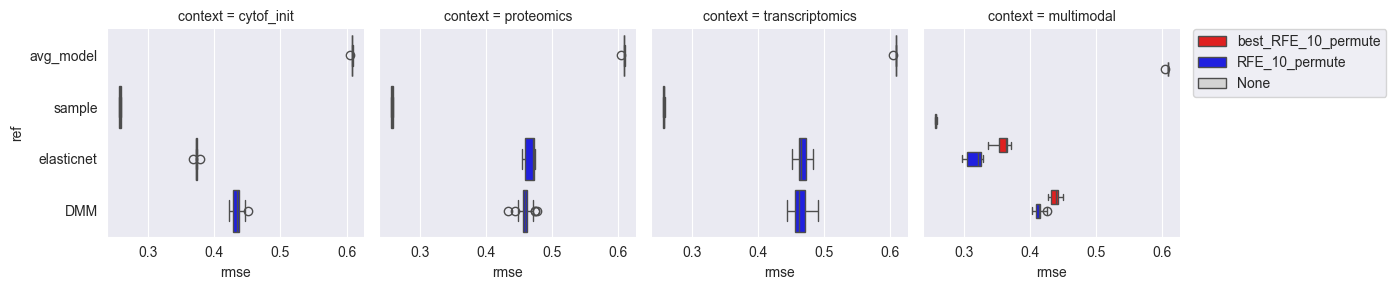

In [9]:
palette = {
    "RFE_10_permute": "blue",
    "HVGRFE_10_permute": "blue",
    "best_RFE_10_permute": "red",
    "None": "lightgray"
}

g = sns.FacetGrid(
    reduced_train_df,
    col="context",
    col_order=["cytof_init", "proteomics", "transcriptomics", "multimodal"]
)

g.map_dataframe(
    sns.boxplot,
    y="ref",
    x="rmse",
    order=["avg_model", "sample", "elasticnet", "DMM"],
    hue="features",
    palette=palette
)

plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

## Validation

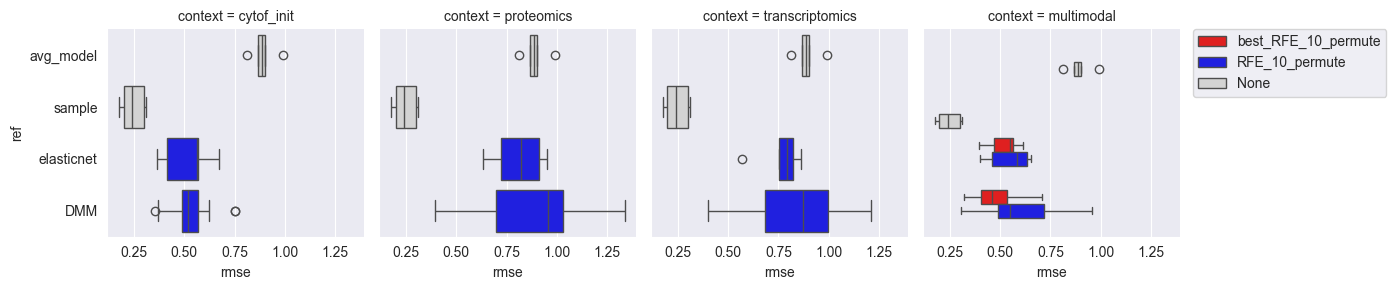

In [10]:
palette = {
    "RFE_10_permute": "blue",
    "HVGRFE_10_permute": "blue",
    "best_RFE_10_permute": "red",
    "None": "lightgray"
}

g = sns.FacetGrid(
    reduced_val_df,
    col="context",
    col_order=["cytof_init", "proteomics", "transcriptomics", "multimodal"]
)

g.map_dataframe(
    sns.boxplot,
    y="ref",
    x="rmse",
    order=["avg_model", "sample", "elasticnet", "DMM"],
    hue="features",
    palette=palette
)

plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

## Generalisation Gap

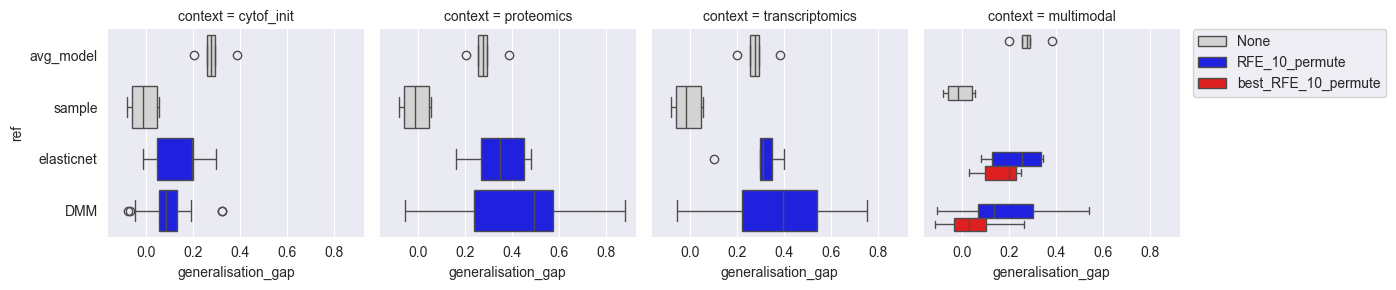

In [11]:
palette = {
    "RFE_10_permute": "blue",
    "HVGRFE_10_permute": "blue",
    "best_RFE_10_permute": "red",
    "None": "lightgray"
}

g = sns.FacetGrid(
    reduced_gen_gap_df,
    col="context",
    col_order=["cytof_init", "proteomics", "transcriptomics", "multimodal"]
)

g.map_dataframe(
    sns.boxplot,
    y="ref",
    x="generalisation_gap",
    order=["avg_model", "sample", "elasticnet", "DMM"],
    hue="features",
    palette=palette
)

plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

# As best_RFE_10_permute outperforms RFE_10_permute for multimodal, at least when it comes to validation & generalisation gap, we can subset to that feature selection strategy only and rather look at sample split

In [12]:
reduced_val_df = reduced_val_df[~((reduced_val_df["context"] == "multimodal") &
                  (reduced_val_df["features"] == "RFE_10_permute"))]

reduced_gen_gap_df = reduced_gen_gap_df[~((reduced_gen_gap_df["context"] == "multimodal") &
                  (reduced_gen_gap_df["features"] == "RFE_10_permute"))]

In [13]:
reduced_val_df["group"] = reduced_val_df["context"] + "_" + reduced_val_df["ref"]

In [ ]:
# reduced_val_df = reduced_val_df[
#     (~reduced_val_df.ref.isin(["avg_model", "sample"])) |
#     (reduced_val_df.context == "cytof_init")
# ]

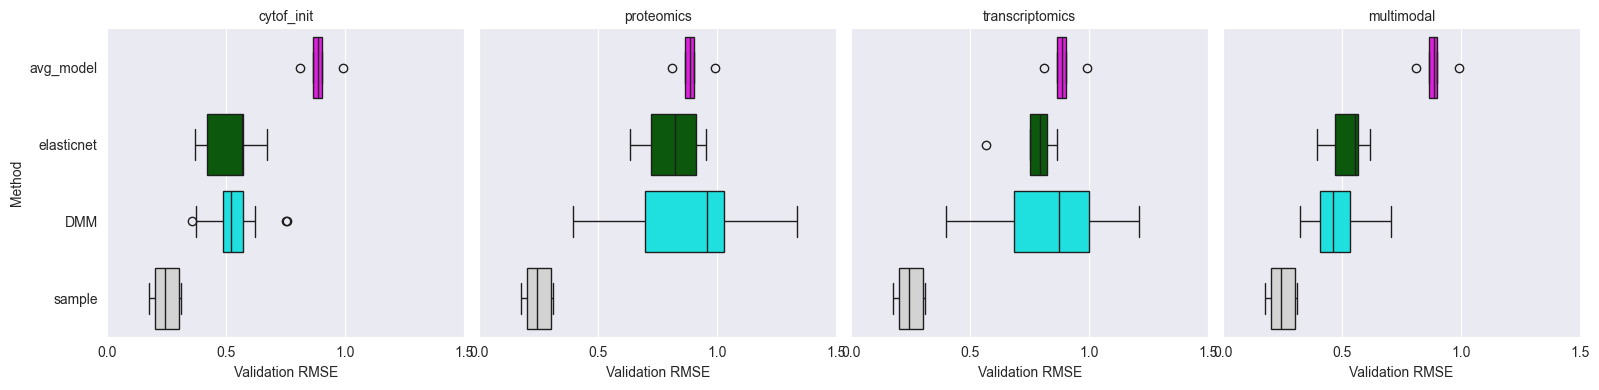

In [14]:
g = sns.FacetGrid(
    reduced_val_df,
    col="context",
    col_order=["cytof_init", "proteomics", "transcriptomics", "multimodal"],
    height=4,
    aspect=1,
)

g.map_dataframe(
    sns.boxplot,
    y="ref",
    x="rmse",
    order=["avg_model", "elasticnet", "DMM", "sample"],
    hue="ref",
    palette={
        "avg_model": "fuchsia",
        "sample": "lightgray",
        "DMM": "cyan",
        "elasticnet": "darkgreen",
    },
    hue_order=["avg_model", "elasticnet", "DMM", "sample"],
)

# Axis labels
g.set_axis_labels("Validation RMSE", "Method")

# Remove the "context = " prefix from column titles
g.set_titles(col_template="{col_name}")

plt.xlim([0, 1.5])
plt.xticks([0, 0.50, 1.00, 1.50])

plt.savefig("base_fig1a_all_contexts.svg")

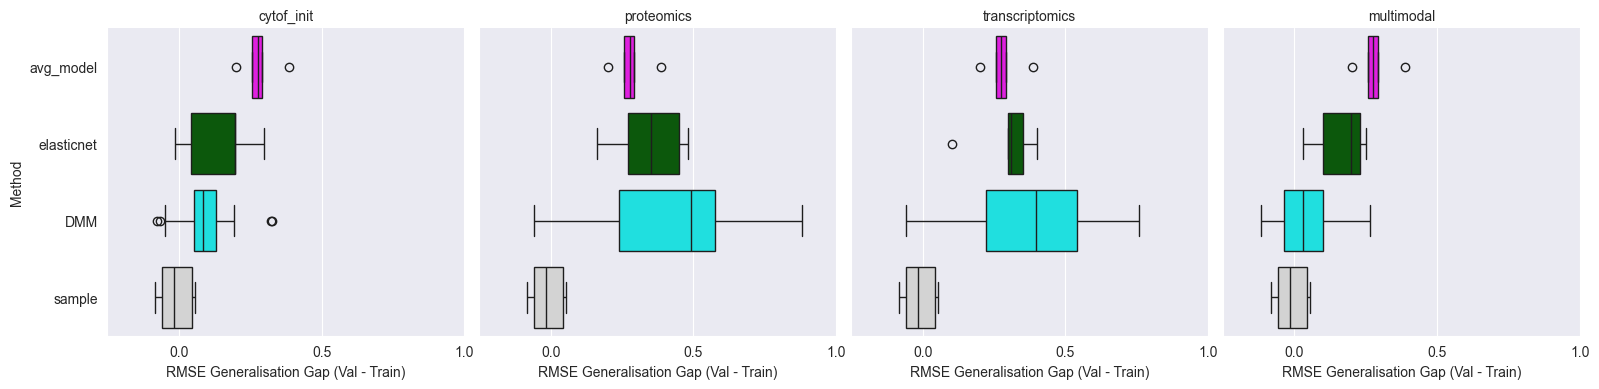

In [15]:
g = sns.FacetGrid(
    reduced_gen_gap_df,
    col="context",
    col_order=["cytof_init", "proteomics", "transcriptomics", "multimodal"],
    height=4,
    aspect=1,
)

g.map_dataframe(
    sns.boxplot,
    y="ref",
    x="generalisation_gap",
    order=["avg_model", "elasticnet", "DMM", "sample"],
    hue="ref",
    palette={
        "avg_model": "fuchsia",
        "sample": "lightgray",
        "DMM": "cyan",
        "elasticnet": "darkgreen",
    },
    hue_order=["avg_model", "elasticnet", "DMM", "sample"],
)

# Axis labels
g.set_axis_labels("RMSE Generalisation Gap (Val - Train)", "Method")

# Remove the "context = " prefix from column titles
g.set_titles(col_template="{col_name}")

plt.xlim([-0.25, 1.00])
plt.xticks([0, 0.50, 1.00])

plt.savefig("base_fig1a_all_contexts_gengap.svg")

# Per CV split plot

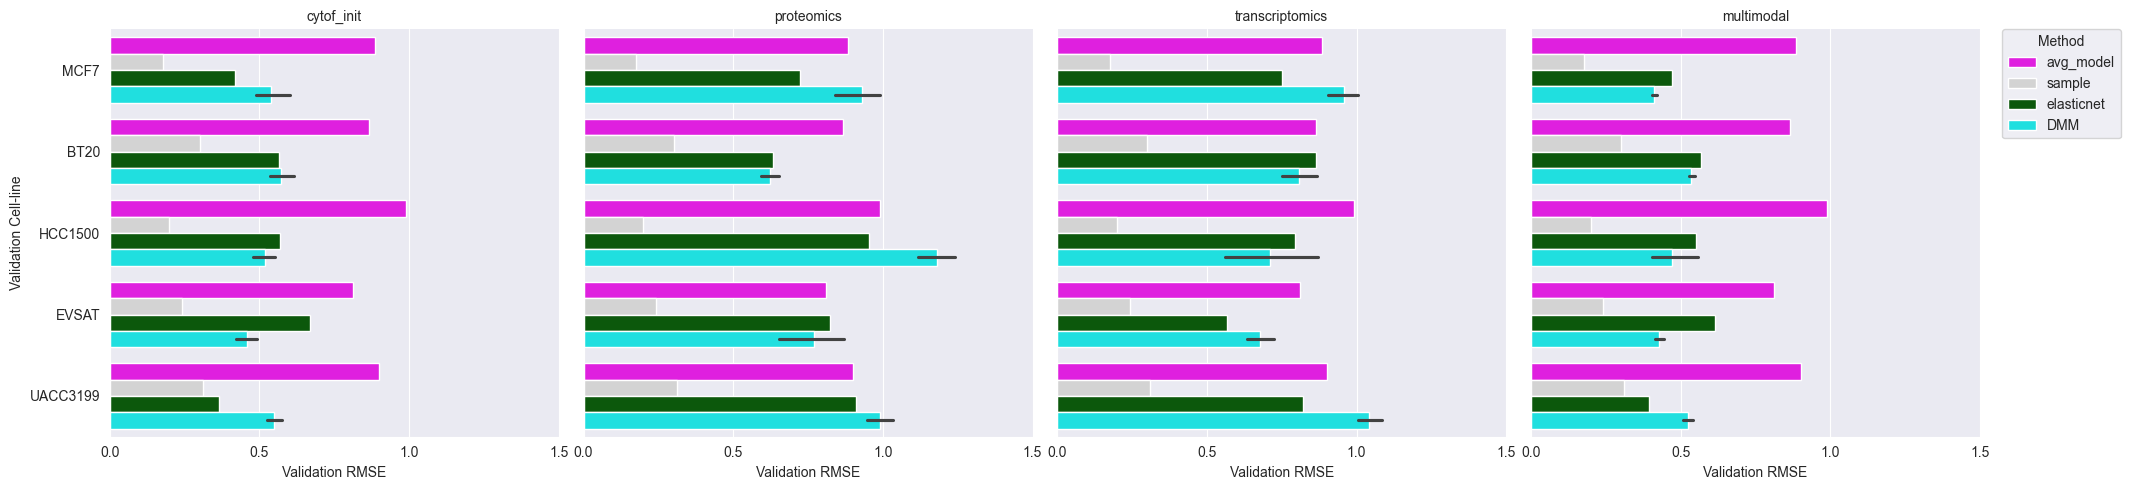

In [16]:
ref_palette = {
        "avg_model": "fuchsia",
        "sample": "lightgray",
        "DMM": "cyan",
        "elasticnet": "darkgreen",
    }
g = sns.FacetGrid(
    reduced_val_df,
    col="context",
    col_order=["cytof_init", "proteomics", "transcriptomics", "multimodal"],
    height=5,
)

g.map_dataframe(
    sns.barplot,
    y="samples",
    x="rmse",
    hue="ref",
    order=["MCF7", "BT20", "HCC1500", "EVSAT", "UACC3199"],
    palette=ref_palette,
    hue_order=["avg_model", "sample", "elasticnet", "DMM"]
)
# Axis labels
g.set_axis_labels("Validation RMSE", "Validation Cell-line")

# Remove the "context = " prefix from column titles
g.set_titles(col_template="{col_name}")

plt.xlim([0, 1.5])
plt.xticks([0, 0.50, 1.00, 1.50])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., title="Method")

plt.savefig("base_fig1a_all_contexts_samplesplit.svg")

In [17]:
val_df.groupby(["context", "features", "ref", "samples"]).rmse.mean()

context          features  ref        samples 
cytof_init       None      avg_model  BT20        0.865491
                                      EVSAT       0.811184
                                      HCC1500     0.990033
                                      MCF7        0.884996
                                      UACC3199    0.900677
                                                    ...   
transcriptomics  None      sample     BT20        0.301176
                                      EVSAT       0.242057
                                      HCC1500     0.199262
                                      MCF7        0.176687
                                      UACC3199    0.311391
Name: rmse, Length: 140, dtype: float64

# Looking at best performing model (`multimodal`): is it statistically significantly better than the regressors? No.

In [18]:
val_df[
        val_df.ref.isin(["DMM"])
        & val_df.model.isin(["EGFR_MAPK__logobs",])
        & (val_df.context == "multimodal")
        & (val_df.features == "best_RFE_10_permute")
    ].sort_values(
        by=["context", "samples", "job"]
    ).groupby(["context", "samples"]).rmse.mean()

context     samples 
multimodal  BT20        0.536252
            EVSAT       0.429186
            HCC1500     0.470611
            MCF7        0.411245
            UACC3199    0.525742
Name: rmse, dtype: float64

In [19]:
val_df[
        val_df.ref.isin(["elasticnet"])
        & val_df.model.isin(["EGFR_MAPK__logobs",])
        & (val_df.context == "multimodal")
        & (val_df.features == "best_RFE_10_permute")
    ].sort_values(
        by=["context", "samples", "job"]
    )[["samples", "rmse"]]

,samples,rmse
165,BT20,0.566790
168,EVSAT,0.615871
171,HCC1500,0.552332
174,MCF7,0.471146
177,UACC3199,0.395423


In [20]:
from scipy import stats

groups = [
    val_df[
        val_df.ref.isin(["DMM"])
        & val_df.model.isin(["EGFR_MAPK__logobs",])
        & (val_df.context == "multimodal")
        & (val_df.features == "best_RFE_10_permute")
    ].sort_values(
        by=["context", "samples", "job"]
    ).groupby(["context", "samples"]).rmse.mean().values,
    val_df[
        val_df.ref.isin(["elasticnet"])
        & val_df.model.isin(["EGFR_MAPK__logobs",])
        & (val_df.context == "multimodal")
        & (val_df.features == "best_RFE_10_permute")
    ].sort_values(
        by=["context", "samples", "job"]
    ).rmse.values,
]
stat, p = stats.wilcoxon(*groups, alternative="two-sided")
print(f"Wilcoxon signed-rank: W={stat}, p={p:.4g}")

Wilcoxon signed-rank: W=4.0, p=0.4375


In [78]:
subtypes_marcotte[subtypes_marcotte.index.isin(["cMCF7", "cBT20", "cHCC1500", "cEVSAT", "cUACC3199"])].sort_index().subtype_intrinsic

cell_line
cBT20           Basal
cEVSAT           HER2
cHCC1500     LuminalA
cMCF7        LuminalA
cUACC3199       Basal
Name: subtype_intrinsic, dtype: object